In [1]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']= (12, 5)

In [36]:
monthly_df = pd.read_csv('/content/drive/MyDrive/morocco-purchasing-power/hcp_monthly_category_clean.csv')
yearly_df = pd.read_csv('/content/drive/MyDrive/morocco-purchasing-power/hcp_yearly_category_clean.csv')
city_df = pd.read_csv('/content/drive/MyDrive/morocco-purchasing-power/hcp_city_indices_clean.csv')

In [37]:
print(monthly_df["date"].dtype)

object


In [38]:
monthly_df["date"] = pd.to_datetime(monthly_df["date"])
yearly_df["date"] = pd.to_datetime(yearly_df["date"])
city_df["date"] = pd.to_datetime(city_df["date"])

print(monthly_df["date"].dtype)

datetime64[ns]


**Overal CPI Trend (2009 - 2026)**

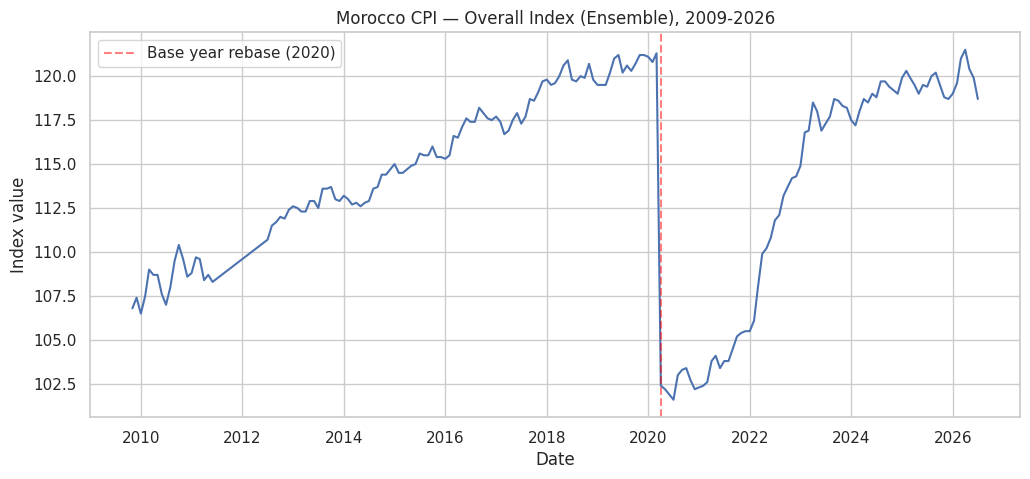

In [39]:
ensemble = monthly_df[monthly_df["category"] == "Ensemble"].sort_values("date")

plt.plot(ensemble["date"], ensemble["index_curr_period"])
plt.title("Morocco CPI — Overall Index (Ensemble), 2009-2026")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.axvline(pd.Timestamp("2020-04-01").to_pydatetime(), color="red", linestyle="--", alpha=0.5, label="Base year rebase (2020)")
plt.legend()
plt.show()

**Food vs Non-food**

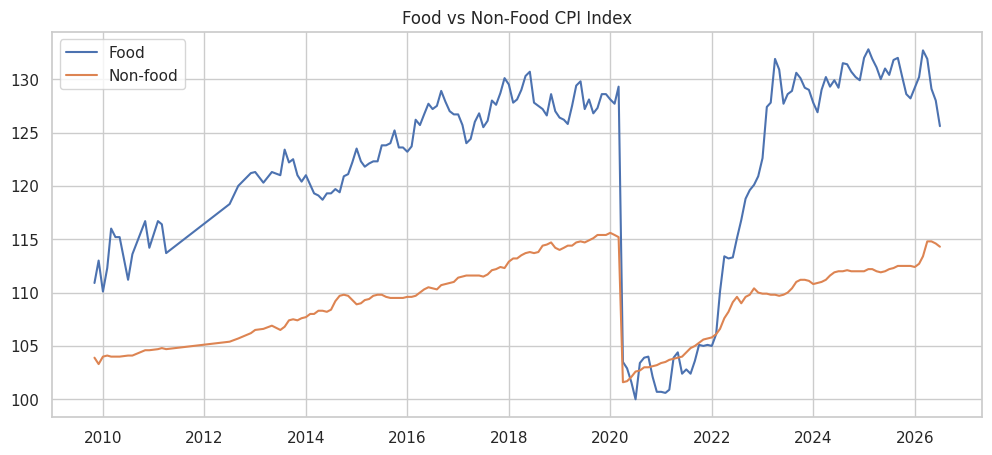

In [40]:
food = monthly_df[monthly_df["category"]=="Produits alimentaires"].sort_values("date")
nonfood = monthly_df[monthly_df["category"]=="Produits non alimentaires"].sort_values("date")

plt.plot(food["date"], food["index_curr_period"], label="Food")
plt.plot(nonfood["date"], nonfood["index_curr_period"], label="Non-food")
plt.title("Food vs Non-Food CPI Index")
plt.legend()
plt.show()

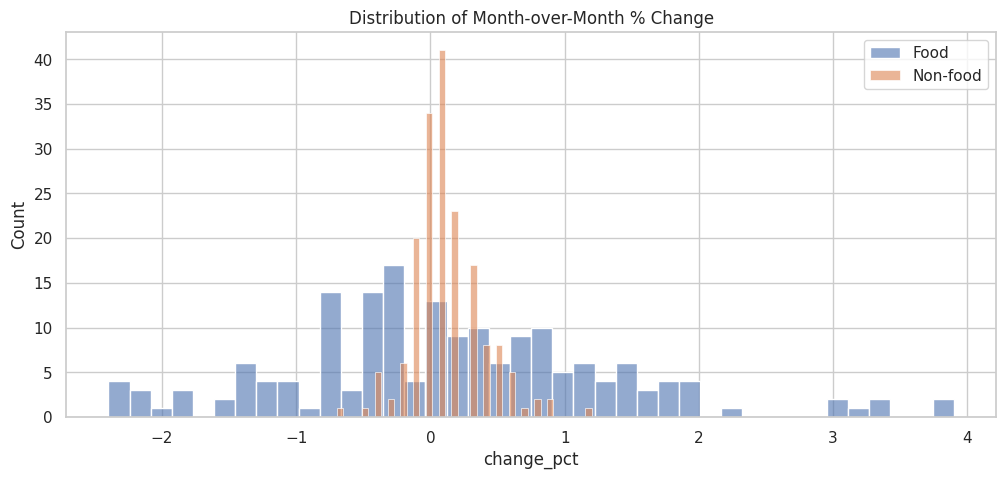

Food change_pct std: 1.1976321120910456
Non-food change_pct std: 0.2624237116135886


In [41]:
fig, ax = plt.subplots()
sns.histplot(food["change_pct"], bins=40, label="Food", alpha=0.6, ax=ax)
sns.histplot(nonfood["change_pct"], bins=40, label="Non-food", alpha=0.6, ax=ax)
ax.set_title("Distribution of Month-over-Month % Change")
ax.legend()
plt.show()

print("Food change_pct std:", food["change_pct"].std())
print("Non-food change_pct std:", nonfood["change_pct"].std())

**Category % change( split by base-year period )**

In [42]:
categories = monthly_df[~monthly_df["category"].isin(["Ensemble","Produits alimentaires","Produits non alimentaires"])]


                                                    pct_change_2009_2020  \
category                                                                   
07 - Transport                                                  6.286267   
02 - Boissons alcoolisées et tabac                             47.319778   
01 - Produits alimentaires et boissons non alco...             15.301530   
11 - Restaurants et hôtels                                     25.046382   
12 - Biens et services divers                                  17.769376   
03 - Articles d'habillement et chaussures                      14.107486   
10 - Enseignement                                              39.099735   
05 - Meubles, articles de ménage et entretien c...              6.723485   
04 - Logement, eau, électricité et autres combu...             13.064361   
09 - Loisirs et culture                                         3.673469   
06 - Santé                                                      5.165692   
08 - Communi

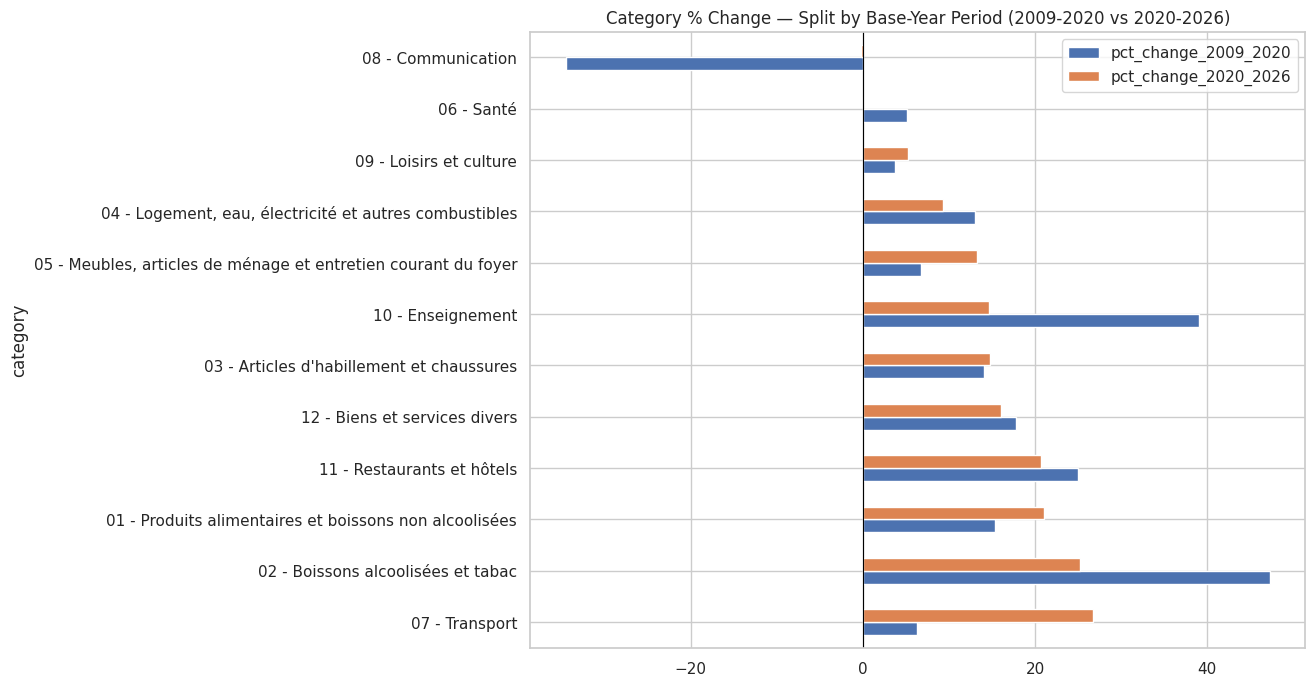

In [43]:
rebase_date = pd.Timestamp("2020-04-01")

categories_sorted = categories.sort_values("date")  # <-- the missing step

pre_rebase = categories_sorted[categories_sorted["date"] < rebase_date]
post_rebase = categories_sorted[categories_sorted["date"] >= rebase_date]

pre_change = pre_rebase.groupby("category").agg(
    first_val=("index_curr_period","first"), last_val=("index_curr_period","last")
)
pre_change["pct_change_2009_2020"] = (pre_change["last_val"]/pre_change["first_val"] - 1) * 100

post_change = post_rebase.groupby("category").agg(
    first_val=("index_curr_period","first"), last_val=("index_curr_period","last")
)
post_change["pct_change_2020_2026"] = (post_change["last_val"]/post_change["first_val"] - 1) * 100

comparison = pre_change[["pct_change_2009_2020"]].join(post_change[["pct_change_2020_2026"]])
comparison = comparison.sort_values("pct_change_2020_2026", ascending=False)
print(comparison)

comparison.plot(kind="barh", figsize=(10,8))
plt.title("Category % Change — Split by Base-Year Period (2009-2020 vs 2020-2026)")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

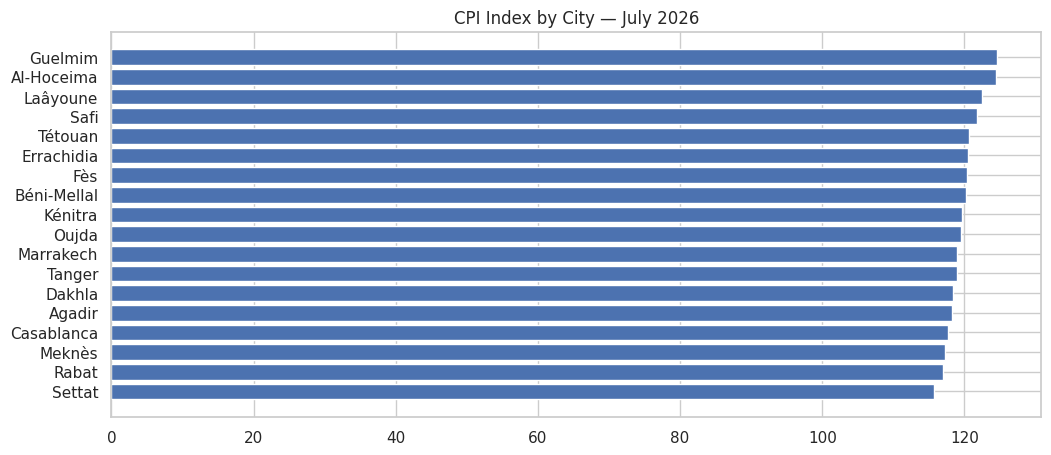

In [44]:
latest_date = city_df["date"].max()
latest_city = city_df[(city_df["date"]==latest_date) & (city_df["city"]!="Ensemble")].sort_values("index_curr_period")

plt.barh(latest_city["city"], latest_city["index_curr_period"])
plt.title(f"CPI Index by City — {latest_date.strftime('%B %Y')}")
plt.show()

In [45]:
city_volatility = city_df[city_df["city"]!="Ensemble"].groupby("city")["change_pct"].std().sort_values(ascending=False)
print(city_volatility)

city
Al-Hoceima     1.276824
Béni-Mellal    1.000024
Errachidia     0.917735
Safi           0.877309
Oujda          0.796970
Guelmim        0.769811
Dakhla         0.765233
Settat         0.753051
Laâyoune       0.748520
Fès            0.708717
Meknès         0.701321
Kénitra        0.665318
Tétouan        0.663695
Tanger         0.636583
Agadir         0.591762
Marrakech      0.589937
Casablanca     0.554616
Rabat          0.509758
Name: change_pct, dtype: float64


**Communication index over time**



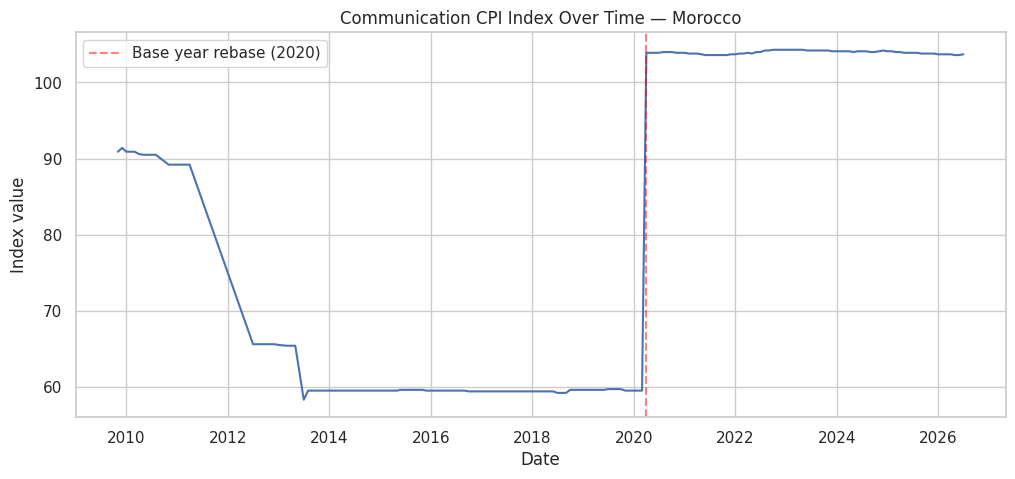

In [46]:
comm = monthly_df[monthly_df["category"]=="08 - Communication"].sort_values("date")

plt.plot(comm["date"], comm["index_curr_period"])
plt.axvline(pd.Timestamp("2020-04-01"), color="red", linestyle="--", alpha=0.5, label="Base year rebase (2020)")
plt.title("Communication CPI Index Over Time — Morocco")
plt.xlabel("Date")
plt.ylabel("Index value")
plt.legend()
plt.show()

**Seasonality (average monthly change)**

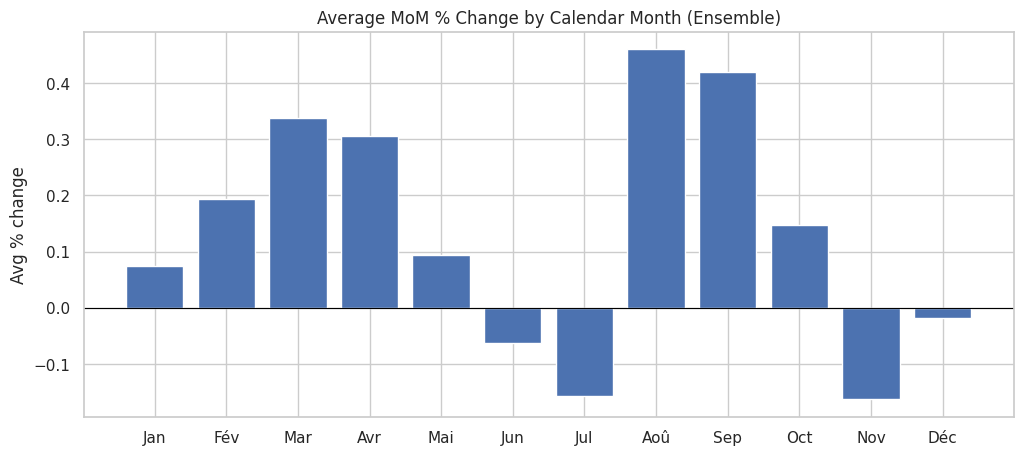

date
1     0.075000
2     0.193750
3     0.337500
4     0.306250
5     0.093750
6    -0.062500
7    -0.156250
8     0.460000
9     0.420000
10    0.146667
11   -0.162500
12   -0.018750
Name: change_pct, dtype: float64


In [47]:
monthly_avg = monthly_df[monthly_df["category"]=="Ensemble"].groupby(monthly_df["date"].dt.month)["change_pct"].mean()

month_labels = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
plt.bar(month_labels, monthly_avg.values)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average MoM % Change by Calendar Month (Ensemble)")
plt.ylabel("Avg % change")
plt.show()

print(monthly_avg)

**Clothing seasonality**

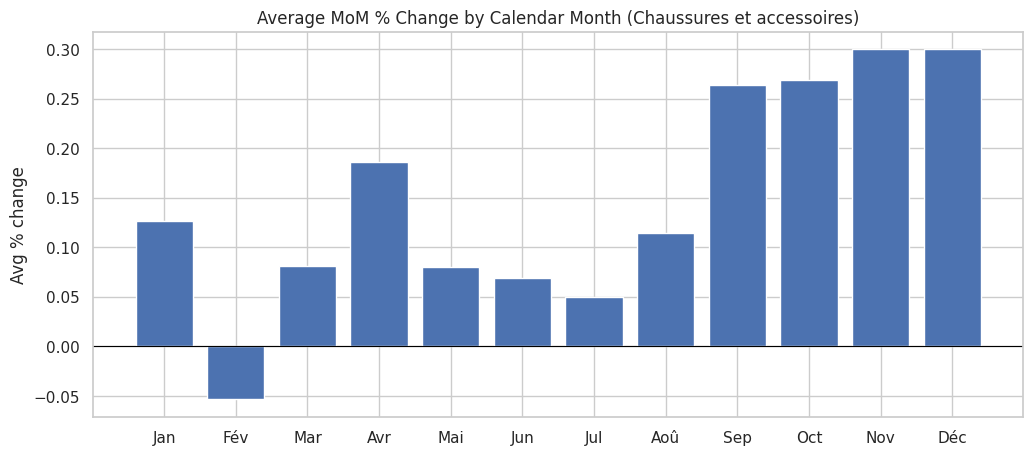

In [48]:
clothing = monthly_df[monthly_df["category"]=="03 - Articles d'habillement et chaussures"]
clothing_by_month = clothing.groupby(clothing["date"].dt.month)["change_pct"].mean()

month_labels = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
plt.bar(month_labels, clothing_by_month.values)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Average MoM % Change by Calendar Month (Chaussures et accessoires)")
plt.ylabel("Avg % change")
plt.show()

**City comparaison ( latest month )**

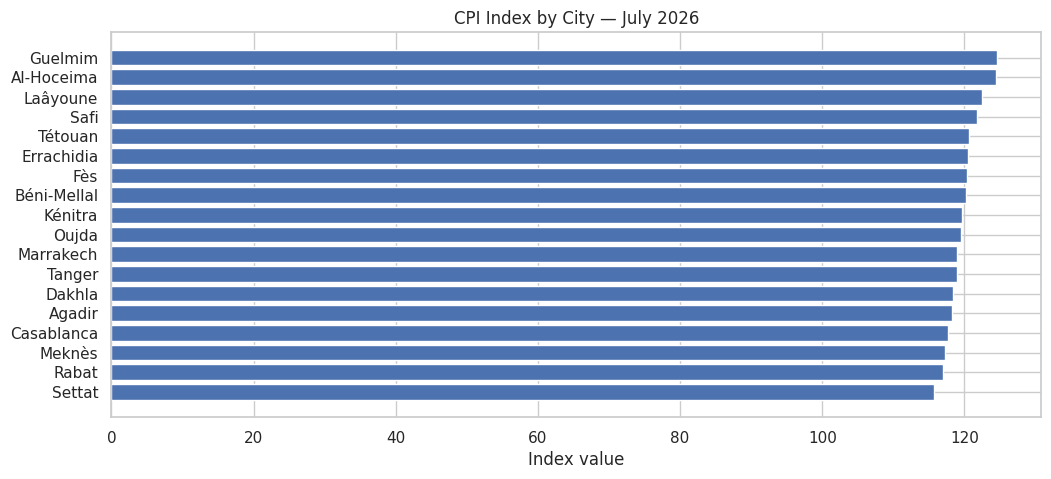

           city  index_curr_period
13       Settat              115.7
6         Rabat              117.0
8        Meknès              117.2
1    Casablanca              117.7
0        Agadir              118.3
11       Dakhla              118.4
9        Tanger              118.9
4     Marrakech              119.0
5         Oujda              119.5
3       Kénitra              119.7
15  Béni-Mellal              120.2
2           Fès              120.3
17   Errachidia              120.5
7       Tétouan              120.7
14         Safi              121.7
10     Laâyoune              122.4
16   Al-Hoceima              124.4
12      Guelmim              124.6


In [49]:
latest_date = city_df["date"].max()
latest_city = city_df[(city_df["date"]==latest_date) & (city_df["city"]!="Ensemble")].sort_values("index_curr_period")

plt.barh(latest_city["city"], latest_city["index_curr_period"])
plt.title(f"CPI Index by City — {latest_date.strftime('%B %Y')}")
plt.xlabel("Index value")
plt.show()

print(latest_city[["city","index_curr_period"]])


**City volatility**

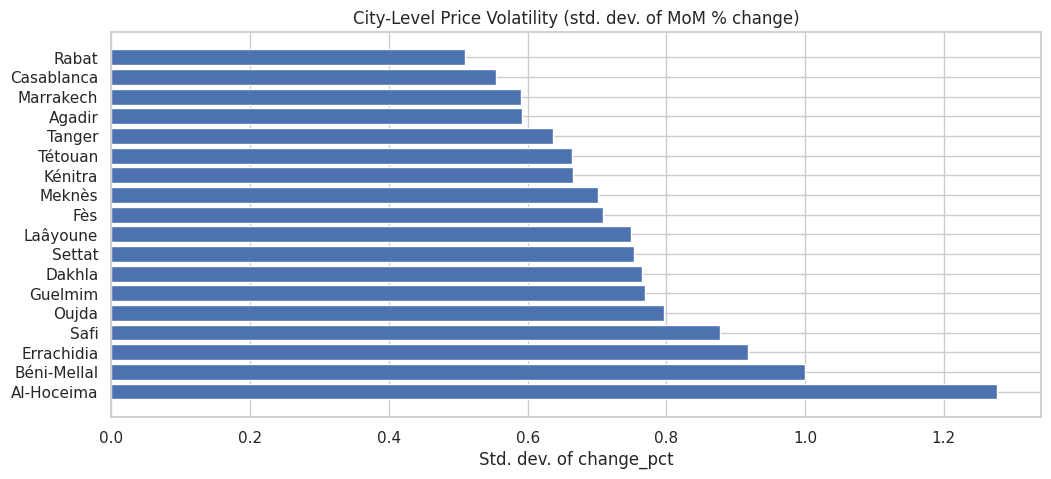

city
Al-Hoceima     1.276824
Béni-Mellal    1.000024
Errachidia     0.917735
Safi           0.877309
Oujda          0.796970
Guelmim        0.769811
Dakhla         0.765233
Settat         0.753051
Laâyoune       0.748520
Fès            0.708717
Meknès         0.701321
Kénitra        0.665318
Tétouan        0.663695
Tanger         0.636583
Agadir         0.591762
Marrakech      0.589937
Casablanca     0.554616
Rabat          0.509758
Name: change_pct, dtype: float64


In [50]:
city_volatility = city_df[city_df["city"]!="Ensemble"].groupby("city")["change_pct"].std().sort_values(ascending=False)

plt.barh(city_volatility.index, city_volatility.values)
plt.title("City-Level Price Volatility (std. dev. of MoM % change)")
plt.xlabel("Std. dev. of change_pct")
plt.show()

print(city_volatility)

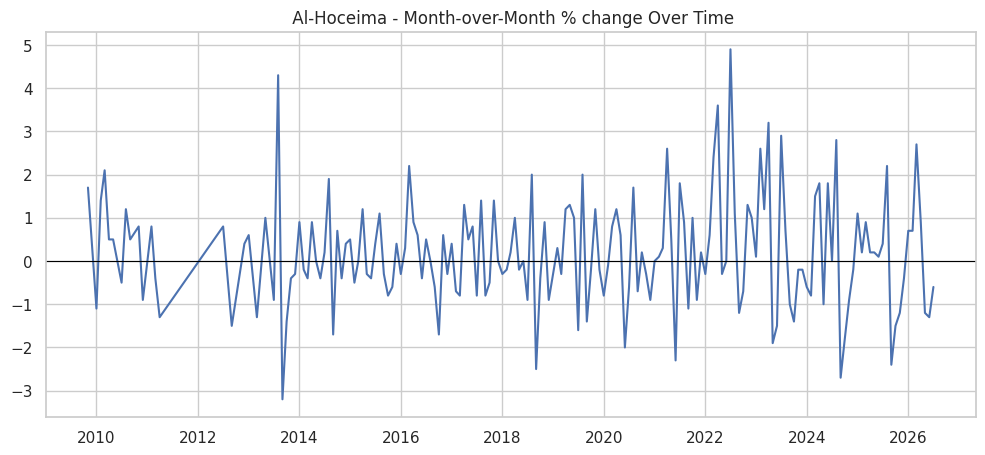

In [51]:
al_hoceima = city_df[city_df["city"]=="Al-Hoceima"].sort_values("date")
plt.plot(al_hoceima["date"], al_hoceima["change_pct"])
plt.axhline(0, color = "black" , linewidth = 0.8 )
plt.title(" Al-Hoceima - Month-over-Month % change Over Time")
plt.show()

In [52]:
print(al_hoceima.nlargest(5, "change_pct")[["date","change_pct"]])
print(al_hoceima.nsmallest(5, "change_pct")[["date","change_pct"]])

           date  change_pct
928  2022-07-01         4.9
2882 2013-08-01         4.3
985  2022-04-01         3.6
757  2023-04-01         3.2
700  2023-07-01         2.9
           date  change_pct
2864 2013-09-01        -3.2
434  2024-09-01        -2.7
1784 2018-09-01        -2.5
206  2025-09-01        -2.4
1175 2021-06-01        -2.3


## Summary

**Overal CPI Trend (2009, 2026)**

Overall CPI trend (2009–2026): The CPI generally increased over the whole period. However, there is a sharp change in April 2020. This is because the base year changed (from 2006 to 2017), not real deflation. So, comparisons across the full period need to take this change into account.


**Food vs Non-food**
Food and non-food prices follow a similar overall trend. However, food prices change more from month to month, which is likely because of seasonal changes and changes in commodity prices.

**Category % change( split by base-year period )**
When we separate the data into the periods before and after the 2020 base-year change, almost all categories show real price increases in both periods. The main exception is Communication, which fell by about 33% between 2009 and 2020. This is a genuine, well-documented event: Morocco's telecom regulator (ANRT) introduced rules that lowered interconnection prices between 2010 and 2013. During this period, telecom prices reportedly fell by about 34%.

**Communication index over time**
The data shows that the fall in communication prices happened mainly between 2011 and 2013. It was a sudden drop rather than a slow decline. This matches the timing of the ANRT price-cap measures.

**Seasonality (average monthly change)**
August and September have the largest increases. This may be related to higher costs during the back-to-school period. July and November show small decreases. Looking at clothing prices suggests that clothing is not the reason for these decreases. Food and fresh produce seasonality is a more likely explanation, although this was not confirmed separately.

**Clothing seasonality**
Clothing prices are usually highest from September to December and lowest in February. This is different from the pattern seen in the overall data, so clothing is unlikely to explain the July and November decreases.

**City comparaison ( latest month )**
There is about an 8-point difference between the cities with the highest CPI (Guelmim and Al-Hoceima) and the lowest (Settat). Tanger is around the middle of the range.

**City volatility**
Al-Hoceima is a clear outlier because its CPI changes much more than in other cities. Its volatility is about twice that of the next most volatile city. A closer look shows this isn't random noise. They are concentrated around a large spike and reversal in 2013 and another period of strong changes from 2022 to 2024. The later period matches the wider inflation shock after the pandemic. This suggests that Al-Hoceima's pattern reflects a real local effect, although the changes are stronger than in other cities.